In [16]:
# general libraries
import os # os stands for "operating system" and includes read/write routines etc. 
import numpy as np # by far the most used library for everyday computation
from scipy import stats # here we import a whole sub-library of stats functions
from matplotlib import pyplot as plt # all of our plotting is done with plt
%matplotlib inline 
# %matplotlib notebook # if you need to zoom into a figure, this is the "interactive" mode of IPython

# import rastermap
from rastermap import utils, Rastermap

# 直接指定文件路径，避免每次都弹出文件选择对话框
spks_path = '/Users/liuqr/files/MFiles/Liu_dataAnalysis/original_program/python_program/rastermap/spk_M3.npy'
spks = np.load(spks_path, mmap_mode='r')
n_neurons, n_time = spks.shape
print(f"神经数据加载成功: {n_neurons} 个神经元, {n_time} 个时间点")

# 加载神经元位置数据
xpos = np.load('/Users/liuqr/files/MFiles/Liu_dataAnalysis/original_program/python_program/rastermap/centerX_M3.npy', mmap_mode='r')
ypos = np.load('/Users/liuqr/files/MFiles/Liu_dataAnalysis/original_program/python_program/rastermap/centerY_M3.npy', mmap_mode='r')

try: 
    contrast_timeseries = np.load('/Users/liuqr/files/MFiles/Liu_dataAnalysis/original_program/python_program/rastermap/contrast_stamp.npy').flatten() 
    result_timeseries = np.load('/Users/liuqr/files/MFiles/Liu_dataAnalysis/original_program/python_program/rastermap/result_stamp.npy').flatten() 
    print("行为学时间序列数据加载成功。")
    # 检查数据维度是否与神经数据一致
    assert len(contrast_timeseries) == n_time, "Contrast 时间序列长度与神经数据总时长不匹配！"
    assert len(result_timeseries) == n_time, "Result 时间序列长度与神经数据总时长不匹配！"
except FileNotFoundError:
    print("错误：一个或多个行为学 .npy 文件未找到。请确保文件名和路径正确。")
    contrast_timeseries = np.zeros(n_time) # 创建空向量以防后续代码报错
    result_timeseries = np.zeros(n_time)

dat = {
    "spks": spks,
    "xpos": xpos,
    "ypos": ypos,
    "contrast_timeseries": contrast_timeseries,
    "result_timeseries": result_timeseries
}

神经数据加载成功: 495 个神经元, 4320 个时间点
行为学时间序列数据加载成功。


(0.9, 1.1)

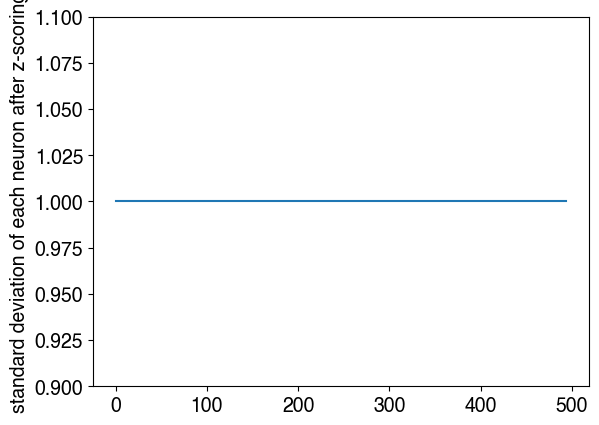

In [21]:
# we will z-score each neuron so that the activity is standard deviation 1 and mean 0 for each neuron
#spks = stats.zscore(spks, axis=1)
#print("Data z-scored")

# REPLACE ????? with the correct function from a package that we already imported (google is your friend)

# colors for the behaviors
result_colors = {0: 'gray', 1: 'green', 2: 'orange', 3: 'red', 4: 'blue'}

plt.plot(spks.std(axis=1))
plt.ylabel('standard deviation of each neuron after z-scoring')
plt.ylim([0.9, 1.1])

(-315.50296410686065,
 381.62117832079934,
 -361.95642722486417,
 335.1677152027958)

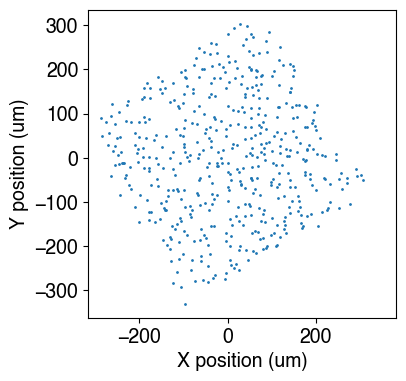

In [22]:
# POSITIONS OF ALL NEURONS
plt.figure(figsize=(4, 4))
plt.scatter(ypos, xpos, s = 1)
plt.xlabel('X position (um)')
plt.ylabel('Y position (um)')
plt.axis("square")

In [23]:
from rastermap import Rastermap

### run rastermap
model = Rastermap(n_clusters=50, n_PCs=128, locality=1,
                  time_lag_window=5).fit(spks)
cc_nodes = model.cc.copy()

# isort contains the neuron indices re-ordered by rastermap
isort = model.isort

# embedding is the embedding position for each neuron from rastermap
embedding = model.embedding[:,0]

2025-07-29 11:07:10,695 [INFO] normalizing data across axis=1
2025-07-29 11:07:10,708 [INFO] projecting out mean along axis=0
2025-07-29 11:07:10,728 [INFO] data normalized, 0.03sec
2025-07-29 11:07:10,733 [INFO] sorting activity: 495 valid samples by 4320 timepoints
2025-07-29 11:07:16,304 [INFO] n_PCs = 128 computed, 5.61sec
2025-07-29 11:07:16,414 [INFO] 48 clusters computed, time 5.72sec
2025-07-29 11:07:17,078 [INFO] clusters sorted, time 6.38sec
2025-07-29 11:07:17,115 [INFO] clusters upsampled, time 6.42sec
2025-07-29 11:07:17,152 [INFO] rastermap complete, time 6.46sec


In [24]:
nbin = 1 # number of neurons to bin over 
ndiv = (n_neurons//nbin) * nbin #maximum number of neurons that is a multiple of nbin

# re-ordering of the rows of the neural activity matrix using the sorting from Rastermap
sn = spks[isort]

# group sorted matrix into rows of length nbin
sn = sn[:ndiv].reshape(ndiv//nbin, nbin, -1)
print(sn.shape)

# take mean over neurons in a bin
sn = sn.mean(axis=1)

print(sn.shape)

(495, 1, 4320)
(495, 4320)


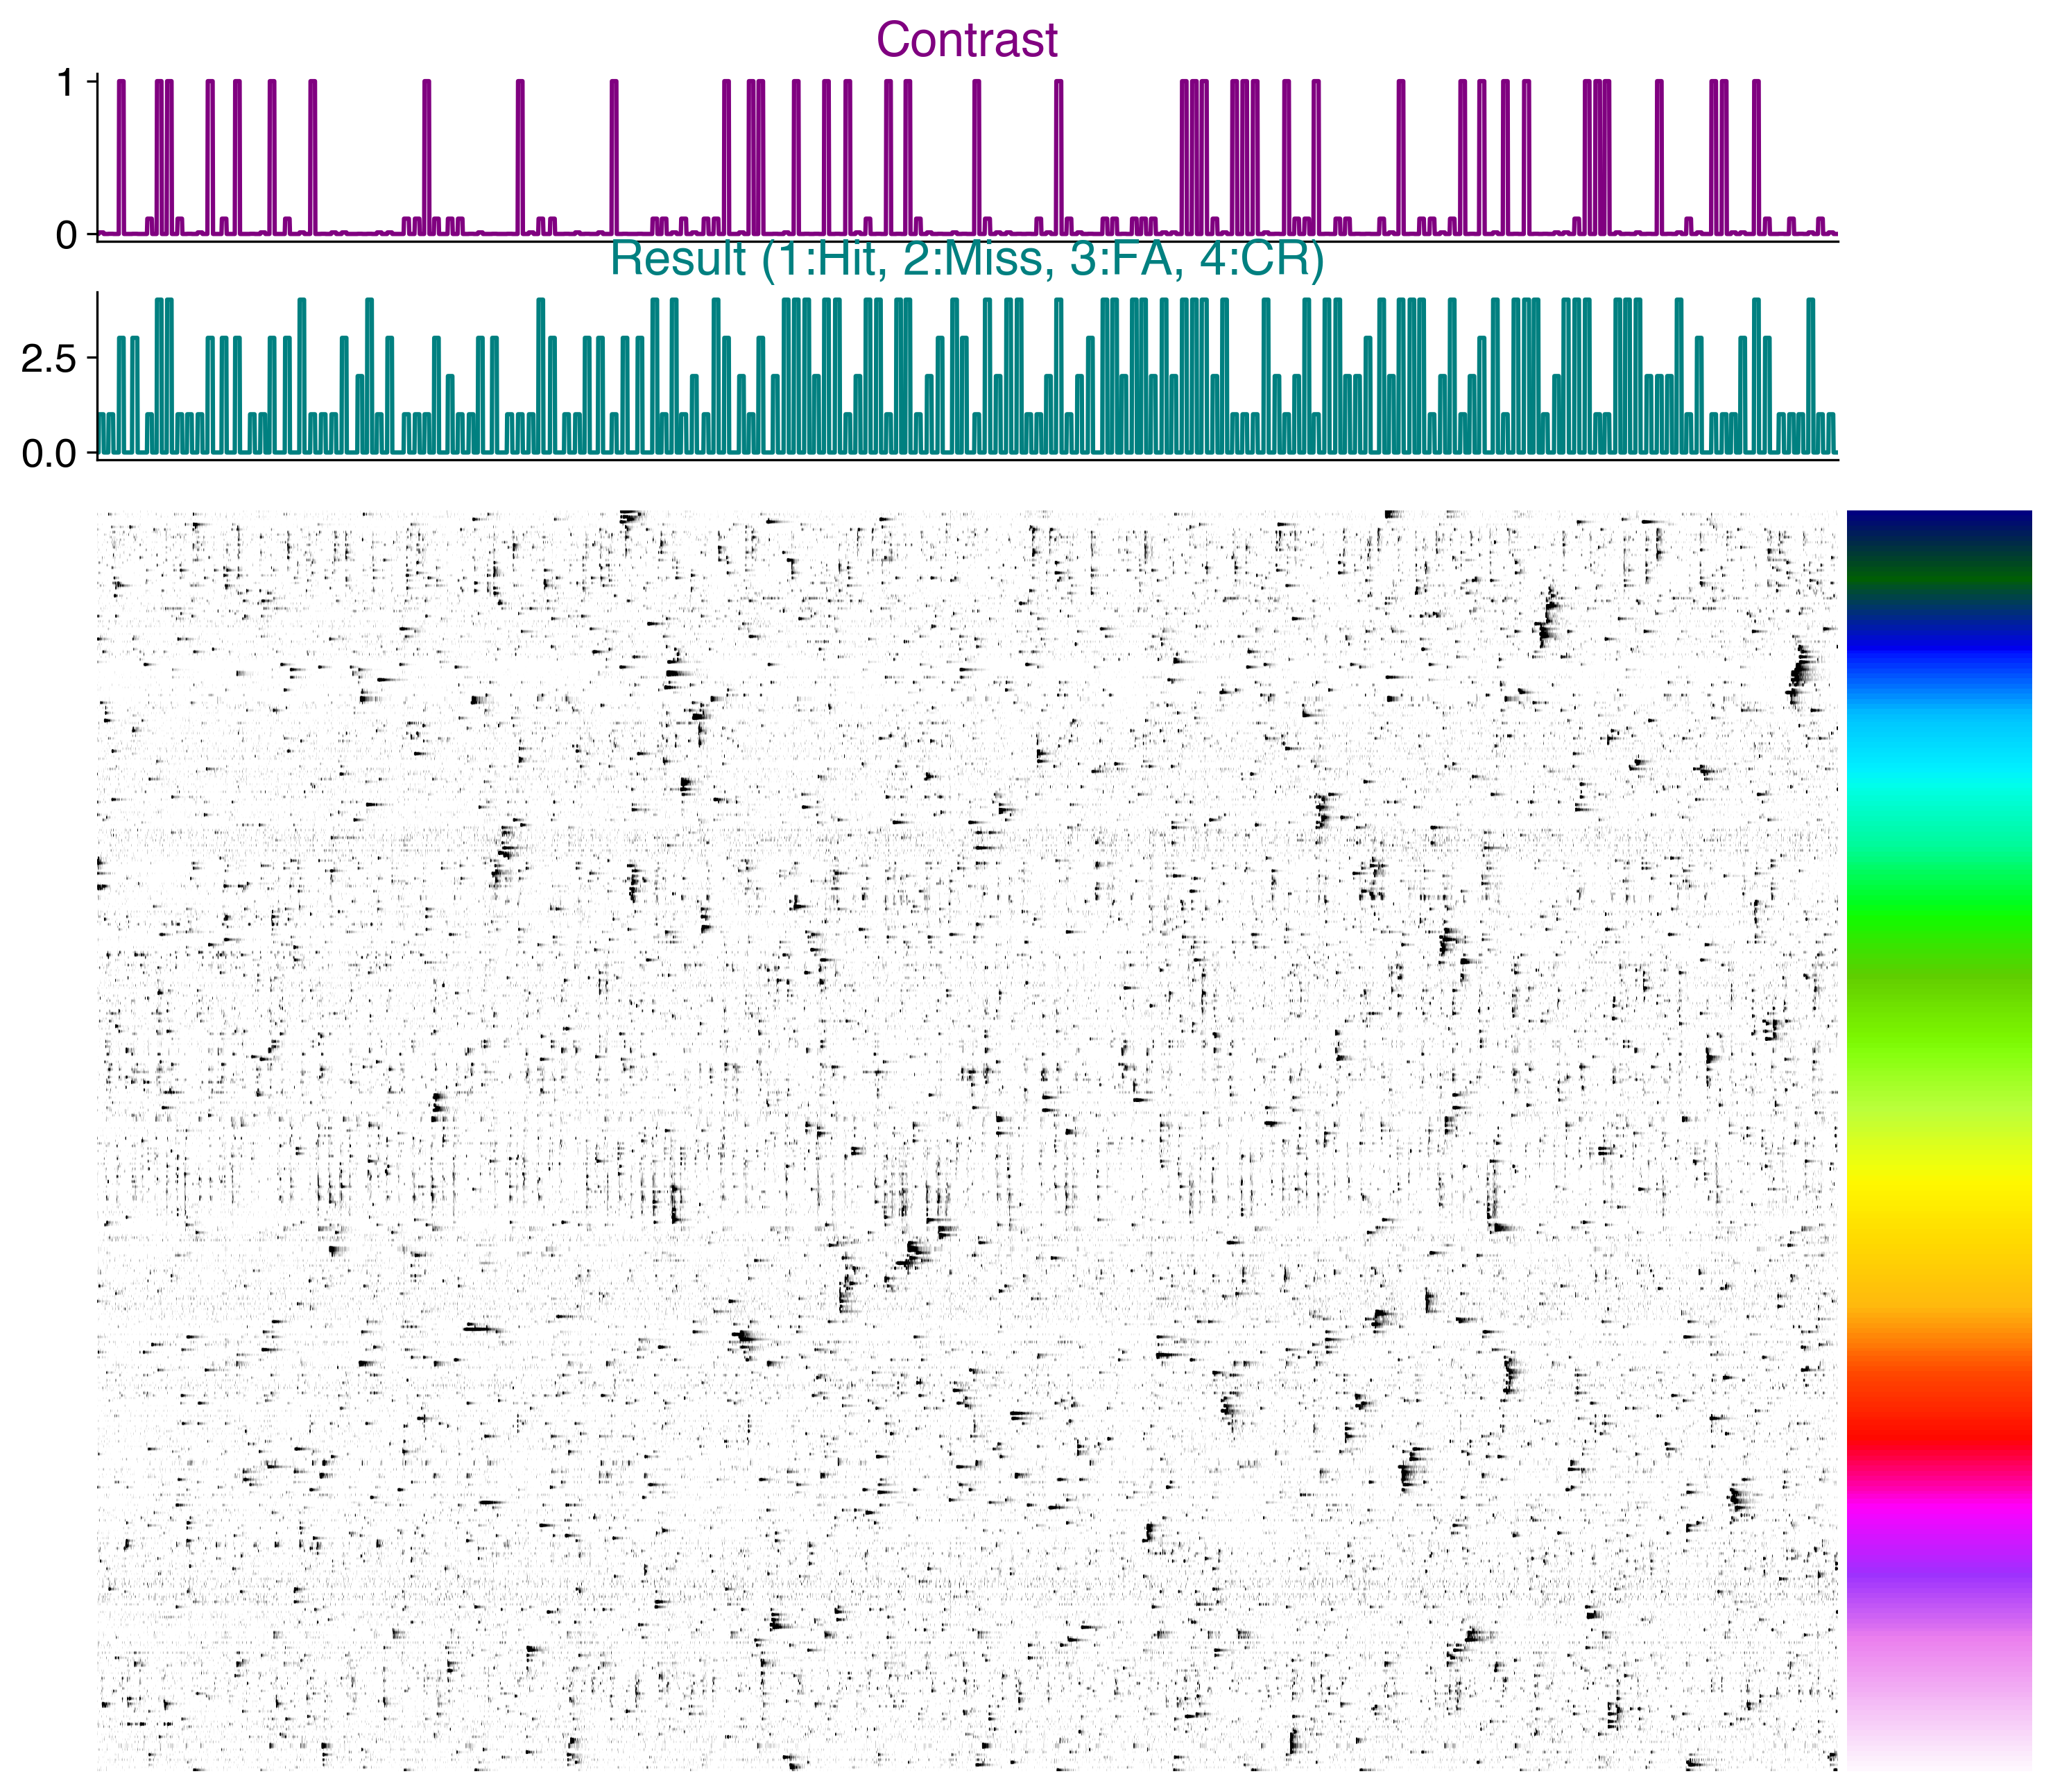

In [25]:
# timepoints to visualize
#set the font size and font family
#set the size of the figure
#set the dpi of the figure
plt.rcParams.update({'font.size': 14, 'font.family': 'helvetica'})
xmin = 0  
xmax = n_time

fig = plt.figure(figsize=(12,12), dpi=300)
grid = plt.GridSpec(8, 10, figure=fig, wspace = 0.05, hspace = 0.3)

# contrast数据
ax_contrast = plt.subplot(grid[0, :-1])
ax_contrast.plot(contrast_timeseries[xmin:xmax], color='purple')
ax_contrast.set_xlim([0, xmax-xmin])
ax_contrast.set_title("Contrast", color='purple')
ax_contrast.spines['top'].set_visible(False)
ax_contrast.spines['right'].set_visible(False)
ax_contrast.xaxis.set_visible(False)

# result数据
ax_result = plt.subplot(grid[1, :-1])
ax_result.plot(result_timeseries[xmin:xmax], color='teal')
ax_result.set_xlim([0, xmax-xmin])
ax_result.set_title("Result (1:Hit, 2:Miss, 3:FA, 4:CR)", color='teal')
ax_result.spines['top'].set_visible(False)
ax_result.spines['right'].set_visible(False)
ax_result.xaxis.set_visible(False)

# 绘制rastermap排序后的神经活动
ax_raster = plt.subplot(grid[2:, :-1])
plt.subplots_adjust(bottom=0.2)

# 使用排序后和平滑后的神经活动
ax_raster.imshow(sn[:, xmin:xmax], cmap="gray_r", vmin=0, vmax=np.percentile(sn, 99), aspect="auto")
ax_raster.set_xlabel("Time (frames)")
ax_raster.set_ylabel("Sorted Neurons (by Rastermap)")
ax_raster.axis("off")

# 绘制神经元排序的颜色条
ax_colorbar = plt.subplot(grid[2:, -1])
ax_colorbar.imshow(np.arange(0, len(sn))[:,np.newaxis], cmap="gist_ncar", aspect="auto")
ax_colorbar.axis("off")

#save the figure as svg
plt.savefig("raster_M3.svg", format="svg")
#save the file as eps
plt.savefig("raster_M3.eps", format="eps")

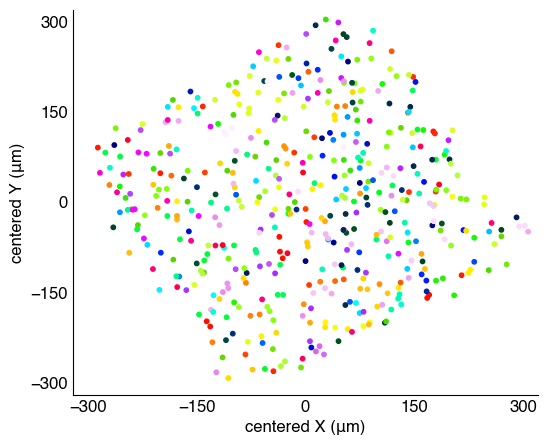

In [26]:
# color the neurons by their position in the rastermap
plt.rcParams.update({'font.size': 12, 'font.family': 'helvetica'})
# POSITIONS OF ALL NEURONS
plt.figure(figsize=(6, 5))

# color the neurons in this plot with c = ?????, where ???? is the embedding position of each neuron from the Rastermap model
#bigger marker size
plt.scatter(ypos, xpos, s=10, c=embedding, cmap="gist_ncar")
plt.xlabel('centered X (μm)')
plt.ylabel('centered Y (μm)')
# hide the tick label length
plt.tick_params(length=0)
#set x tick labels as -300 to 300
plt.xticks([-300, -150, 0, 150, 300])
plt.xlim([-320, 320])

plt.yticks([-300, -150, 0, 150, 300])
plt.ylim([-320, 320])
#hide the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("centeredXY_M3.svg", format="svg")

In [ ]:
#compute the top PCs of the neural data
from sklearn.decomposition import TruncatedSVD

# this function returns the left singular vectors scaled by the singular values
Vsv = TruncatedSVD(n_components = 50).fit_transform(spks.T)

# REPLACE ????? to normalize the singular vectors to unit norm (across time)
V = Vsv.copy() / (Vsv**2).sum(axis=0)**0.5

# project the spiking data onto the singular vectors 
U = spks @ V

# renormalize the neural projections
U /= (U**2).sum(axis=0)**0.5

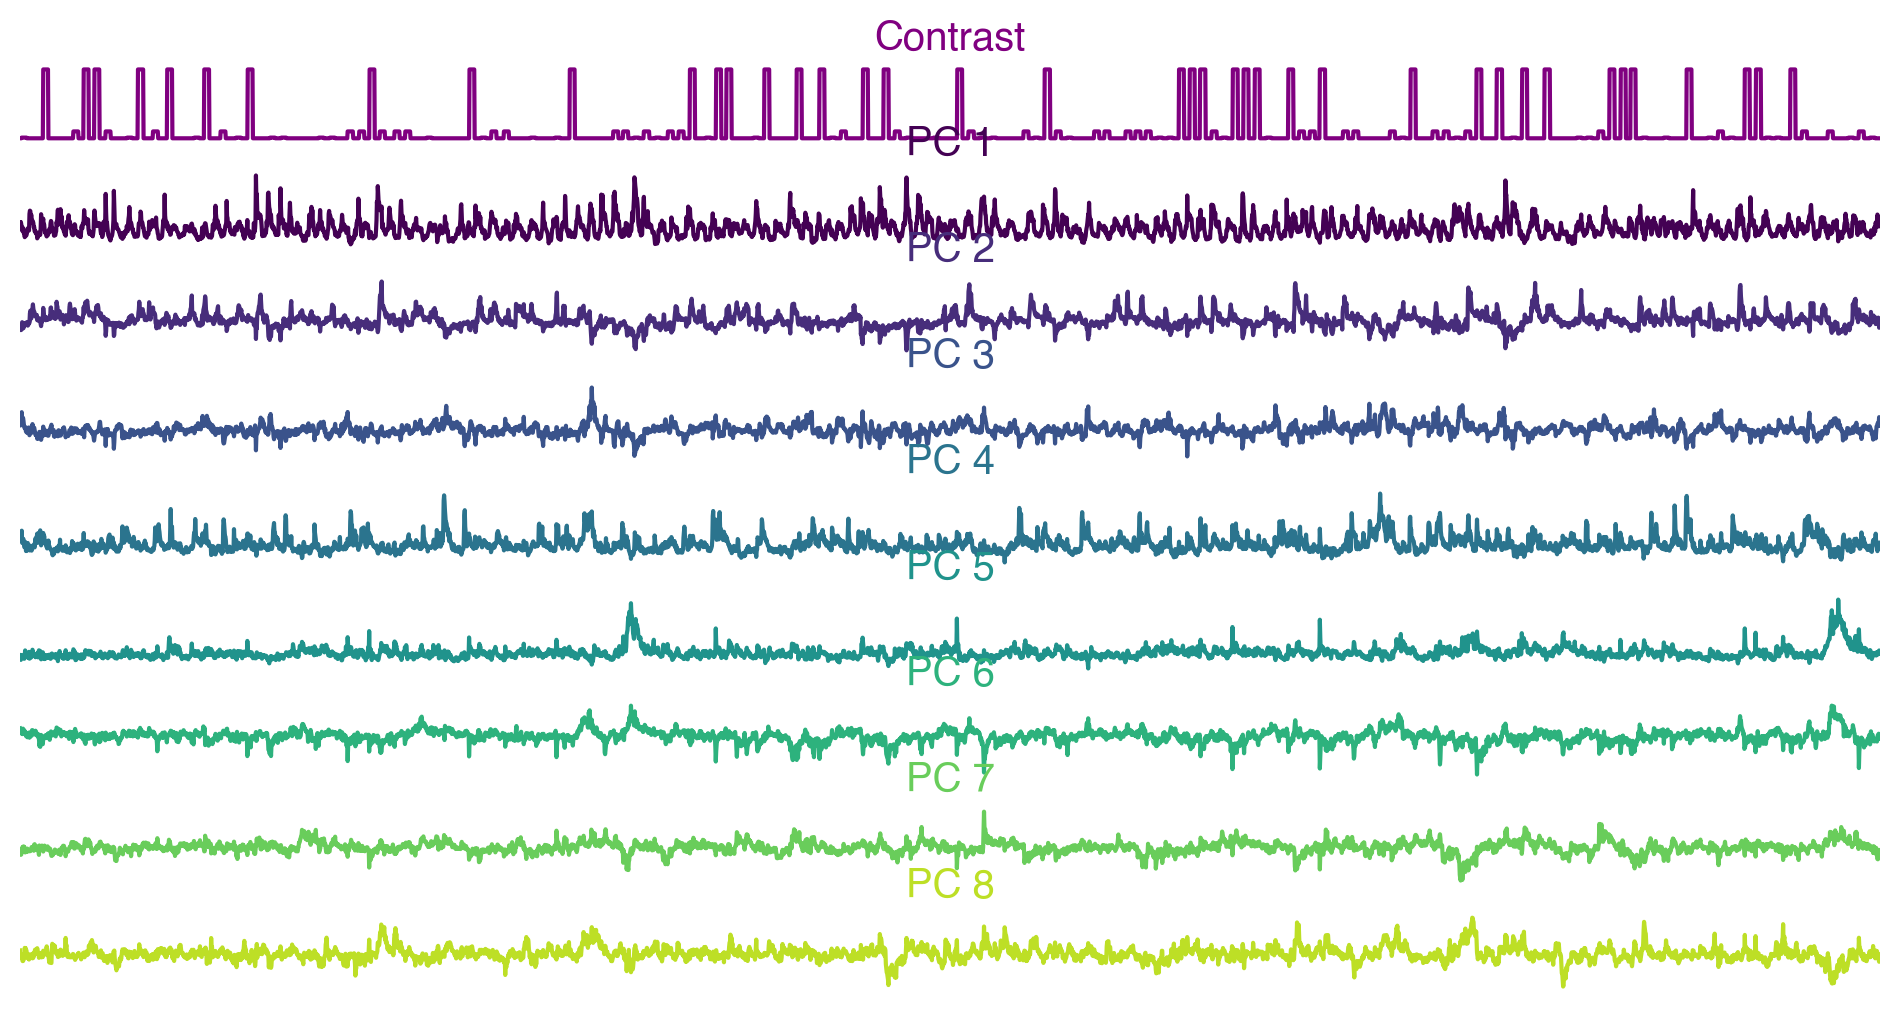

In [27]:
# plot the PCs in time
fig = plt.figure(figsize=(12,6), dpi=200)
grid = plt.GridSpec(9, 1, figure=fig, hspace = 0.4)

# contrast sequence
ax = plt.subplot(grid[0, 0])
ax.plot(contrast_timeseries[xmin:xmax], color='purple')
ax.set_xlim([0, xmax-xmin])
ax.axis("off")
ax.set_title("Contrast", color='purple')

pc_colors = plt.get_cmap("viridis")(np.linspace(0,0.9,8))
for j in range(8):
    ax = plt.subplot(grid[j+1])
    ax.plot(Vsv[xmin:xmax, j], color=pc_colors[j])
    ax.set_xlim([0, xmax-xmin])
    ax.axis("off")
    ax.set_title(f"PC {j+1}", color=pc_colors[j])

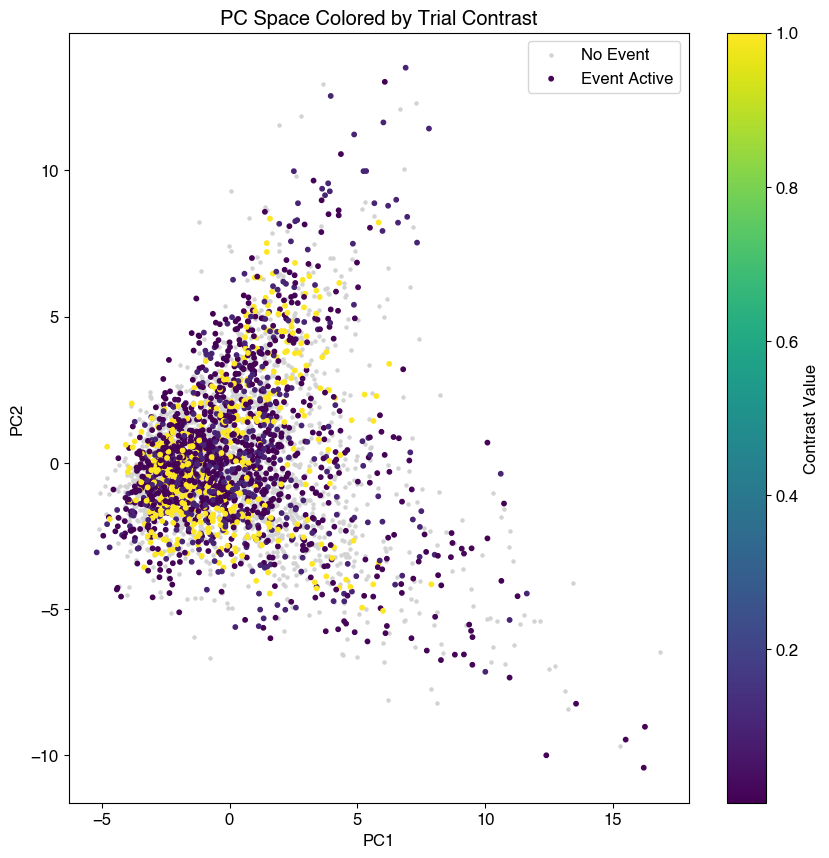

In [29]:
# Make a scatter plot of PC1 vs PC2 across all timepoints. 
# Color the points by running speed. Do you see any structure? 

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111)

# 只对有行为学事件的时间点进行绘制
active_points = contrast_timeseries > 0
ax.scatter(Vsv[~active_points, 0], Vsv[~active_points, 1], c='lightgray', s=5, label='No Event')

#绘制有事件发生的点，并根据 contrast 值着色
sc = ax.scatter(Vsv[active_points, 0], Vsv[active_points, 1], c=contrast_timeseries[active_points], cmap='viridis', s=10, label='Event Active')

plt.colorbar(sc, label='Contrast Value') 
plt.xlabel('PC1') 
plt.ylabel('PC2') 
plt.title('PC Space Colored by Trial Contrast') 
plt.legend() 
plt.show() 

找到了 160 个 trial 时间窗口。


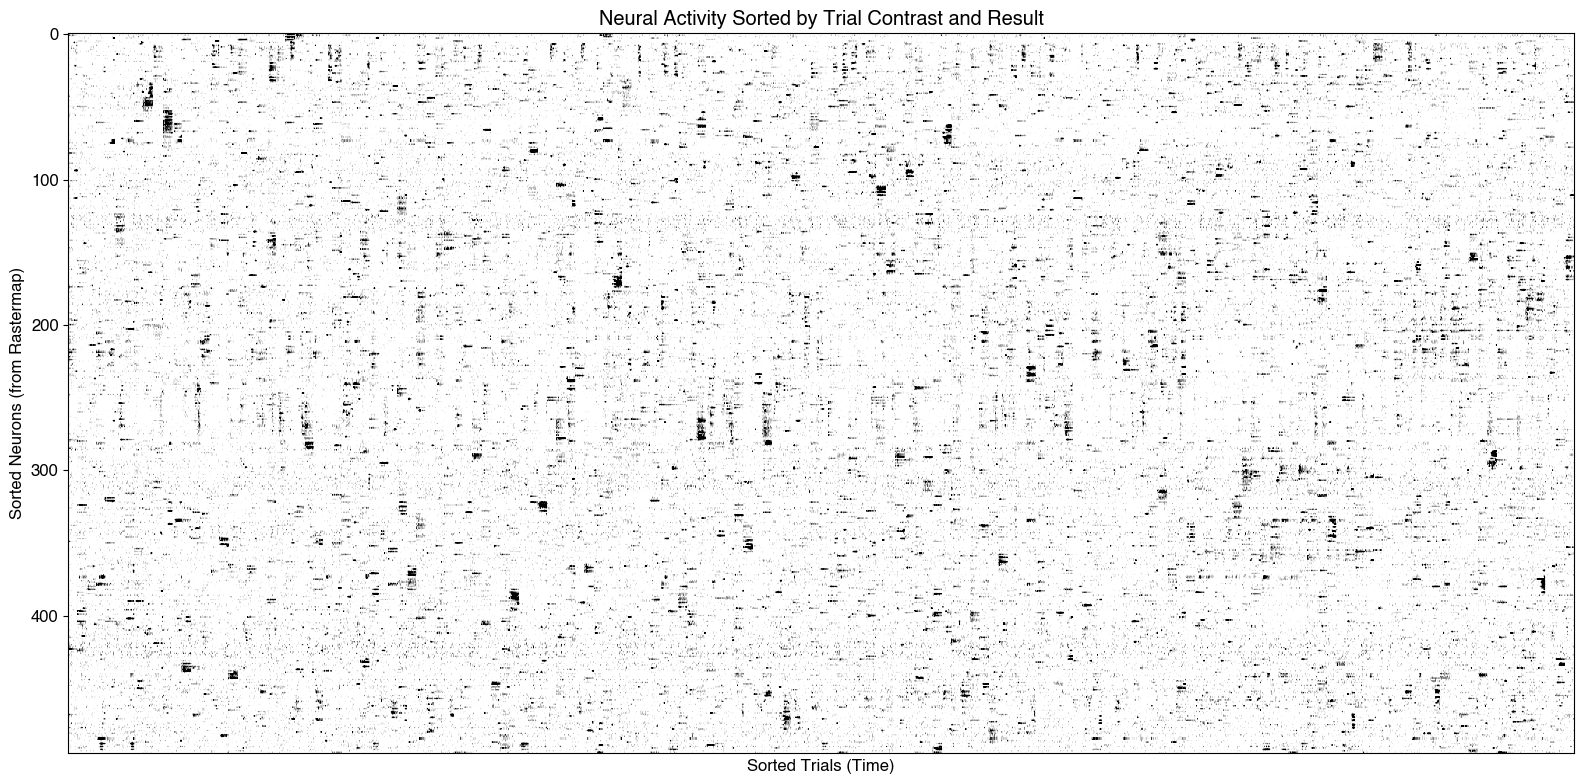

In [ ]:
#根据行为学结果对神经活动进行可视化
# 识别trial的时间窗
from scipy.ndimage import label, find_objects

# result_timeseries 转为整数型标签
labeled, n_trials_found = label(result_timeseries.astype(int))
trial_slices = find_objects(labeled)
print(f"找到了 {n_trials_found} 个 trial 时间窗口。")

# 提取每个trial的信息
trial_info = [] 
for i, slc in enumerate(trial_slices): 
    time_slice = slc[0] # 提取该 trial 的 contrast 和 result (我们取窗口内的第一个非零值) 
    contrast_val = contrast_timeseries[time_slice][0] 
    result_val = result_timeseries[time_slice][0]
    trial_info.append({
        'slice': time_slice,
        'contrast': contrast_val,
        'result': result_val
    })

# 根据contrast和result对trial进行排序
sorted_trial_info = sorted(trial_info, key=lambda x: (x['contrast'], x['result']))

# 提取排序后的神经活动片段
sorted_spks_list = []
for info in sorted_trial_info:
    sorted_spks_list.append(sn[:,info['slice']])

# 将所有片段合并为一个大的矩阵
sorted_activity_trials = np.concatenate(sorted_spks_list,axis = 1)

#可视化排序后的活动
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(sorted_activity_trials, aspect='auto', cmap='gray_r', 
               vmin=0, vmax=np.percentile(sn, 99))
#添加注释和分割线
current_pos = 0
for info in sorted_trial_info:
    duration = info['slice'].stop - info['slice'].start
    current_pos += duration
    # 绘制 trial 分割线
    ax.axvline(current_pos - 0.5, color='white', linestyle='--', linewidth=0.5)

ax.set_title('Neural Activity Sorted by Trial Contrast and Result')
ax.set_xlabel('Sorted Trials (Time)')
ax.set_ylabel('Sorted Neurons (from Rastermap)')
ax.set_xticks([]) # 隐藏x轴刻度
plt.tight_layout()
plt.savefig("raster_M3_sorted_by_behavior.svg", format="svg")
plt.show()

In [36]:
# 用于回归分析的特征矩阵
behavior_features = np.stack((contrast_timeseries, result_timeseries), axis=1)
print("创建的行为特征矩阵 shape:", behavior_features.shape)

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import Ridge 
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split( behavior_features, Vsv, test_size=0.2, shuffle=False)

model = Ridge(alpha=1.0) 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

varexp = r2_score(y_test, y_pred, multioutput='variance_weighted')
print(f"使用您的行为数据预测神经活动PC的方差解释率 (R^2): {varexp:.4f}")


创建的行为特征矩阵 shape: (4320, 2)
使用您的行为数据预测神经活动PC的方差解释率 (R^2): -0.0255
